In [1]:
import pandas as pd
import re
import numpy as np
from pathlib import Path
import os
import random

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


PROJECT_ROOT = Path().resolve().parent.parent
DATA_DIR = PROJECT_ROOT / "data"

# Player Performance  Clustering

Base on the predict scores we have been analyzed eariler. **How can we cluster each player into following levels: Sleeper/Netrual/Bust**

## Data Cleanning

Before we start to doing the full analysis, we need to run some data cleanning steps first.

1. Fix the word issue in csv file to show correct format of years
2. Taking out the missing value and also make sure we only analysis for the palyer which has been player at least more than 20 games and 10 mins in each season to avoid outlier.
3. Creating performance_scores using the following equation:
𝐺𝑚𝑆𝑐 =𝑃𝑇𝑆+0.4∗𝐹𝐺𝑀 −0.7∗𝐹𝐺𝐴−0.4∗(𝐹𝑇𝐴−𝐹𝑇𝑀)+0.7∗ 𝑂𝑅𝐸𝐵+0.3∗𝐷𝑅𝐸𝐵+𝑆𝑇𝐿+0.7∗𝐴𝑆𝑇 +0.7∗𝐵𝐿𝐾−0.4∗𝑃𝐹 −𝑇𝑂V






In [2]:
# read file

df = pd.read_csv(DATA_DIR / "all_player_stats_1999-2025.csv")

# mapping for bad Excel-style season values
season_fix_map = {
    "Jan-00": "2000-01",
    "Feb-01": "2001-02",
    "Mar-02": "2002-03",
    "Apr-03": "2003-04",
    "May-04": "2004-05",
    "Jun-05": "2005-06",
    "Jul-06": "2006-07",
    "Aug-07": "2007-08",
    "Sep-08": "2008-09",
    "Oct-09": "2009-10",
    "Nov-10": "2010-11",
    "Dec-11": "2011-12"
}

# clean season column
df["season"] = df["season"].replace(season_fix_map)

# create year column from the first 4 digits of season
df["year"] = df["season"].str.extract(r"^(\d{4})-").astype(int)

# optional: move year next to season
cols = df.columns.tolist()
season_idx = cols.index("season")
cols.insert(season_idx + 1, cols.pop(cols.index("year")))
df = df[cols]

# create Game Score / performance score
df["performance_score"] = (
    df["PTS"]
    + 0.4 * df["FGM"]
    - 0.7 * df["FGA"]
    - 0.4 * (df["FTA"] - df["FTM"])
    + 0.7 * df["OREB"]
    + 0.3 * df["DREB"]
    + df["STL"]
    + 0.7 * df["AST"]
    + 0.7 * df["BLK"]
    - 0.4 * df["PF"]
    - df["TOV"]
)

# check result
print(df[["PLAYER_NAME", "season", "year", "performance_score"]].head())

      PLAYER_NAME   season  year  performance_score
0      A.C. Green  1999-00  1999              427.3
1   A.J. Bramlett  1999-00  1999               -0.9
2     Aaron McKie  1999-00  1999              516.1
3  Aaron Williams  1999-00  1999              531.7
4      Adam Keefe  1999-00  1999               89.1


In [3]:
# -----------------------------
# 2. Basic playing-time filter
# -----------------------------
# Keep only seasons where player actually played enough
df_clean = df[(df["GP"] > 20) & (df["MIN"] > 10)].copy()

# -----------------------------
# 4. Remove only rows with missing values
# -----------------------------
# This removes only the player-year row that has missing data
df_clean = df_clean.dropna().copy()

print("\nShape after dropping missing rows:")
print(df_clean.shape)

# -----------------------------
# 5. Count number of seasons per player
# -----------------------------
# assuming player name column is PLAYER_NAME
player_season_counts = (
    df_clean.groupby("PLAYER_NAME")
    .size()
    .reset_index(name="n_seasons")
)

# merge season count back to dataframe
df_clean = df_clean.merge(player_season_counts, on="PLAYER_NAME", how="left")


Shape after dropping missing rows:
(10892, 40)


### Finding the performance socres for each player. 

In here, we are trying to find the performace scores for each player which has been played at least for 7 years. It converts data from a season-level table into a player-level modeling table for Goal 1.We will read the all_status_player from 1999-2025. And then find the socres for each player and because of the player-season level dataset, we need average the scores into two parts:

We converted the cleaned season-level dataset into a player-level analysis table by indexing each player’s cleaned seasons in chronological order and retaining only players with at least seven usable seasons. For each player, the first four seasons were summarized using averages, Year 4 values, Year 1-to-Year 4 improvements, and linear slopes over the first four seasons. The realized later-career outcome was summarized using the average performance over Years 5–7 and the total Years 5–7 performance score. These components were merged into one row per player to create the final analysis table used for clustering and predictive modeling.

In [4]:
# Make a safe copy
df_work = df_clean.copy()

# Sort player seasons in time order
df_work = df_work.sort_values(["PLAYER_NAME", "year"]).reset_index(drop=True)

# --------------------------------------------------
# 2. Create season index within each player's career
# --------------------------------------------------
# career_year = 1 means player's first observed cleaned season
df_work["career_year"] = df_work.groupby("PLAYER_NAME").cumcount() + 1

# --------------------------------------------------
# 3. Keep only players with at least 7 cleaned seasons
# --------------------------------------------------
# Because we need:
# first 4 seasons -> input
# next 3 seasons -> Years 5-7 outcome
player_counts = (
    df_work.groupby("PLAYER_NAME")
    .size()
    .reset_index(name="n_seasons")
)

eligible_players = player_counts.loc[player_counts["n_seasons"] >= 7, "PLAYER_NAME"]
df_eligible = df_work[df_work["PLAYER_NAME"].isin(eligible_players)].copy()

# --------------------------------------------------
# 4. Choose variables to summarize
# --------------------------------------------------
base_stats = [
    "GP", "MIN", "PTS", "REB", "AST", "STL", "BLK", "TOV",
    "FG_PCT", "FG3_PCT", "FT_PCT", "performance_score"
]


base_stats = [col for col in base_stats if col in df_eligible.columns]

# --------------------------------------------------
# 5. Build first 4 seasons input block
# --------------------------------------------------
df_input = df_eligible[df_eligible["career_year"].between(1, 4)].copy()

# Average of Years 1-4
input_avg = (
    df_input.groupby("PLAYER_NAME")[base_stats]
    .mean()
    .add_suffix("_1to4_avg")
    .reset_index()
)

# Year 4 values only
year4 = (
    df_input[df_input["career_year"] == 4][["PLAYER_NAME"] + base_stats]
    .copy()
)
year4 = year4.rename(columns={col: f"{col}_year4" for col in base_stats})

# Year 1 values only
year1 = (
    df_input[df_input["career_year"] == 1][["PLAYER_NAME"] + base_stats]
    .copy()
)
year1 = year1.rename(columns={col: f"{col}_year1" for col in base_stats})

# Improvement from Year 1 to Year 4
improve = year1.merge(year4, on="PLAYER_NAME", how="inner")

for col in base_stats:
    improve[f"{col}_improve_y1_to_y4"] = improve[f"{col}_year4"] - improve[f"{col}_year1"]

improve_cols = ["PLAYER_NAME"] + [f"{col}_improve_y1_to_y4" for col in base_stats]
improve = improve[improve_cols]


# Simple slope across Years 1-4
def get_slopes(group, cols):
    out = {"PLAYER_NAME": group.name}
    x = group["career_year"].astype(float).to_numpy()

    for col in cols:
        y = pd.to_numeric(group[col], errors="coerce").to_numpy(dtype=float)
        if len(y) == 4 and np.isfinite(y).all():
            out[f"{col}_slope_1to4"] = np.polyfit(x, y, 1)[0]
        else:
            out[f"{col}_slope_1to4"] = np.nan

    return pd.Series(out)

input_slopes = (
    df_input.groupby("PLAYER_NAME")
    .apply(lambda g: get_slopes(g, base_stats))
    .reset_index(drop=True)
)

# --------------------------------------------------
# 6. Build Years 5-7 realized outcome block
# --------------------------------------------------
df_output = df_eligible[df_eligible["career_year"].between(5, 7)].copy()

output_avg = (
    df_output.groupby("PLAYER_NAME")[base_stats]
    .mean()
    .add_suffix("_5to7_avg")
    .reset_index()
)

# Optional: total Years 5-7 performance score
if "performance_score" in df_output.columns:
    output_total_perf = (
        df_output.groupby("PLAYER_NAME")["performance_score"]
        .sum()
        .reset_index(name="performance_score_5to7_total")
    )
else:
    output_total_perf = pd.DataFrame({"PLAYER_NAME": output_avg["PLAYER_NAME"]})

# --------------------------------------------------
# 7. Merge all player-level pieces together
# --------------------------------------------------
player_analysis_df = (
    input_avg
    .merge(year4, on="PLAYER_NAME", how="inner")
    .merge(improve, on="PLAYER_NAME", how="inner")
    .merge(input_slopes, on="PLAYER_NAME", how="inner")
    .merge(output_avg, on="PLAYER_NAME", how="inner")
    .merge(output_total_perf, on="PLAYER_NAME", how="left")
)


In [5]:
# =========================================================
# 0. Read split/prediction table
# =========================================================

split_df = pd.read_csv(DATA_DIR / "player_train_test_split_with_score.csv").copy()

split_df["PLAYER_ID"] = pd.to_numeric(split_df["PLAYER_ID"], errors="coerce")

# keep only TEST players, one row per player
split_test = (
    split_df[split_df["SPLIT"] == "Test"]
    .drop_duplicates(subset=["PLAYER_ID"])
    .copy()
)

# fix possible name issue
name_fix = {
    "Nikola Vu?evi?": "Nikola Vucevic",
    "Nikola Vučević": "Nikola Vucevic"
}
split_test["PLAYER_NAME"] = split_test["PLAYER_NAME"].replace(name_fix)

# =========================================================
# 1. Make sure player_analysis_df has PLAYER_ID
# =========================================================
player_analysis_work = player_analysis_df.copy()

if "PLAYER_ID" not in player_analysis_work.columns:
    player_id_lookup = (
        df_clean[["PLAYER_NAME", "PLAYER_ID"]]
        .dropna()
        .drop_duplicates()
        .groupby("PLAYER_NAME", as_index=False)["PLAYER_ID"]
        .agg(lambda x: x.value_counts().idxmax())
    )
    player_analysis_work = player_analysis_work.merge(
        player_id_lookup,
        on="PLAYER_NAME",
        how="left"
    )

player_analysis_work["PLAYER_ID"] = pd.to_numeric(player_analysis_work["PLAYER_ID"], errors="coerce")
player_analysis_work["PLAYER_NAME"] = player_analysis_work["PLAYER_NAME"].replace(name_fix)

# =========================================================
# 2. Find unmatched TEST players relative to player_analysis_df
# =========================================================
existing_ids = set(player_analysis_work["PLAYER_ID"].dropna().astype(int))
test_ids = set(split_test["PLAYER_ID"].dropna().astype(int))

unmatched_ids = test_ids - existing_ids
unmatched_test = split_test[split_test["PLAYER_ID"].dropna().astype(int).isin(unmatched_ids)].copy()

print("Original player_analysis_df rows:", player_analysis_work.shape[0])
print("Original player_analysis_df unique PLAYER_ID:", player_analysis_work["PLAYER_ID"].nunique())
print("Unmatched TEST players to rebuild:", unmatched_test["PLAYER_ID"].nunique())

# =========================================================
# 3. Prepare original all-stats table
# =========================================================
df_all = df.copy()
df_all["PLAYER_ID"] = pd.to_numeric(df_all["PLAYER_ID"], errors="coerce")
df_all["PLAYER_NAME"] = df_all["PLAYER_NAME"].replace(name_fix)

# make sure performance_score exists
if "performance_score" not in df_all.columns:
    df_all["performance_score"] = (
        df_all["PTS"]
        + 0.4 * df_all["FGM"]
        - 0.7 * df_all["FGA"]
        - 0.4 * (df_all["FTA"] - df_all["FTM"])
        + 0.7 * df_all["OREB"]
        + 0.3 * df_all["DREB"]
        + df_all["STL"]
        + 0.7 * df_all["AST"]
        + 0.7 * df_all["BLK"]
        - 0.4 * df_all["PF"]
        - df_all["TOV"]
    )

df_all = df_all.sort_values(["PLAYER_ID", "year"]).reset_index(drop=True)
df_all["career_year"] = df_all.groupby("PLAYER_ID").cumcount() + 1

df_unmatched_all = df_all[df_all["PLAYER_ID"].dropna().astype(int).isin(unmatched_ids)].copy()

print("Unmatched TEST players found in all-stats:", df_unmatched_all["PLAYER_ID"].nunique())

# =========================================================
# 4. Build historical/input-side variables for unmatched players
#    Rule:
#    - if player has >= 4 seasons, use first 4 seasons
#    - if player has < 4 seasons, use all available seasons
# =========================================================
base_stats = [
    "GP", "MIN", "PTS", "REB", "AST", "STL", "BLK", "TOV",
    "FG_PCT", "FG3_PCT", "FT_PCT", "performance_score"
]
base_stats = [c for c in base_stats if c in df_unmatched_all.columns]

# count seasons available
season_counts = (
    df_unmatched_all.groupby(["PLAYER_ID", "PLAYER_NAME"])
    .size()
    .reset_index(name="n_seasons_available")
)

df_unmatched_all = df_unmatched_all.merge(
    season_counts,
    on=["PLAYER_ID", "PLAYER_NAME"],
    how="left"
)

# keep first 4 if >=4 seasons, otherwise keep all available
df_input = df_unmatched_all[
    ((df_unmatched_all["n_seasons_available"] >= 4) & (df_unmatched_all["career_year"].between(1, 4))) |
    ((df_unmatched_all["n_seasons_available"] < 4))
].copy()

# averages over available input window
input_avg = (
    df_input.groupby(["PLAYER_ID", "PLAYER_NAME"])[base_stats]
    .mean()
    .add_suffix("_1to4_avg")
    .reset_index()
)

# first observed season values
year1 = (
    df_input.sort_values(["PLAYER_ID", "career_year"])
    .groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .first()[["PLAYER_ID", "PLAYER_NAME"] + base_stats]
    .copy()
)
year1 = year1.rename(columns={col: f"{col}_year1" for col in base_stats})

# last used season values
year_last = (
    df_input.sort_values(["PLAYER_ID", "career_year"])
    .groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .last()[["PLAYER_ID", "PLAYER_NAME"] + base_stats]
    .copy()
)
year_last = year_last.rename(columns={col: f"{col}_year4" for col in base_stats})

# improvement from first observed to last used
improve = year1.merge(year_last, on=["PLAYER_ID", "PLAYER_NAME"], how="inner")
for col in base_stats:
    improve[f"{col}_improve_y1_to_y4"] = improve[f"{col}_year4"] - improve[f"{col}_year1"]

improve_cols = ["PLAYER_ID", "PLAYER_NAME"] + [f"{col}_improve_y1_to_y4" for col in base_stats]
improve = improve[improve_cols]

# slopes across available input seasons
def get_slopes(group, cols):
    player_id, player_name = group.name   # comes from groupby(["PLAYER_ID", "PLAYER_NAME"])
    
    out = {
        "PLAYER_ID": player_id,
        "PLAYER_NAME": player_name
    }
    
    x = group["career_year"].astype(float).to_numpy()

    for col in cols:
        y = pd.to_numeric(group[col], errors="coerce").to_numpy(dtype=float)
        if len(y) >= 2 and np.isfinite(y).all():
            out[f"{col}_slope_1to4"] = np.polyfit(x, y, 1)[0]
        else:
            out[f"{col}_slope_1to4"] = np.nan

    return pd.Series(out)

input_slopes = (
    df_input.groupby(["PLAYER_ID", "PLAYER_NAME"])
    .apply(lambda g: get_slopes(g, base_stats))
    .reset_index(drop=True)
)

# =========================================================
# 5. Use predicted future values from split file for unmatched players
# =========================================================
pred_future = unmatched_test.copy()

# derive pct columns if needed
if "FG_PCT_5to7_avg" not in pred_future.columns and {"FGM", "FGA"}.issubset(pred_future.columns):
    pred_future["FG_PCT_5to7_avg"] = pred_future["FGM"] / pred_future["FGA"].replace(0, np.nan)

if "FG3_PCT_5to7_avg" not in pred_future.columns and {"FG3M", "FG3A"}.issubset(pred_future.columns):
    pred_future["FG3_PCT_5to7_avg"] = pred_future["FG3M"] / pred_future["FG3A"].replace(0, np.nan)

if "FT_PCT_5to7_avg" not in pred_future.columns and {"FTM", "FTA"}.issubset(pred_future.columns):
    pred_future["FT_PCT_5to7_avg"] = pred_future["FTM"] / pred_future["FTA"].replace(0, np.nan)

# find score column safely
possible_score_cols = [
    "Game_Score",
    "game_score",
    "performance_score",
    "performance_score_5to7_avg",
    "GameScore"
]

future_score_col = None
for col in possible_score_cols:
    if col in pred_future.columns:
        future_score_col = col
        break

if future_score_col is None:
    raise ValueError("No future score column found in split file.")

future_keep_cols = ["PLAYER_ID", "PLAYER_NAME"]
future_map = {}

# only keep columns that exist
candidate_cols = {
    "MIN": "MIN_5to7_avg",
    "PTS": "PTS_5to7_avg",
    "REB": "REB_5to7_avg",
    "AST": "AST_5to7_avg",
    future_score_col: "performance_score_5to7_avg",
    "FG_PCT_5to7_avg": "FG_PCT_5to7_avg",
    "FG3_PCT_5to7_avg": "FG3_PCT_5to7_avg",
    "FT_PCT_5to7_avg": "FT_PCT_5to7_avg"
}

for old_col, new_col in candidate_cols.items():
    if old_col in pred_future.columns:
        future_keep_cols.append(old_col)
        future_map[old_col] = new_col

pred_future_block = pred_future[future_keep_cols].copy().rename(columns=future_map)

# =========================================================
# 6. Rebuild unmatched rows
# =========================================================
unmatched_rebuilt = (
    input_avg
    .merge(year_last, on=["PLAYER_ID", "PLAYER_NAME"], how="inner")
    .merge(improve, on=["PLAYER_ID", "PLAYER_NAME"], how="inner")
    .merge(input_slopes, on=["PLAYER_ID", "PLAYER_NAME"], how="inner")
    .merge(pred_future_block, on=["PLAYER_ID", "PLAYER_NAME"], how="left")
)

unmatched_rebuilt["has_full_1to4_and_5to7"] = False

# =========================================================
# 7. Append unmatched rebuilt rows INTO original player_analysis_df
# =========================================================
all_cols = sorted(set(player_analysis_work.columns).union(set(unmatched_rebuilt.columns)))

player_analysis_base = player_analysis_work.reindex(columns=all_cols)
unmatched_rebuilt = unmatched_rebuilt.reindex(columns=all_cols)

player_analysis_df_match = pd.concat(
    [player_analysis_base, unmatched_rebuilt],
    axis=0,
    ignore_index=True
)

player_analysis_df_match = player_analysis_df_match.sort_values(
    ["PLAYER_ID", "PLAYER_NAME"]
).reset_index(drop=True)

# =========================================================
# 8. Final checks
# =========================================================
print("player_analysis_df original shape:", player_analysis_work.shape)
print("unmatched_rebuilt shape:", unmatched_rebuilt.shape)
print("player_analysis_df_match final shape:", player_analysis_df_match.shape)

Original player_analysis_df rows: 674
Original player_analysis_df unique PLAYER_ID: 674
Unmatched TEST players to rebuild: 19
Unmatched TEST players found in all-stats: 19
player_analysis_df original shape: (674, 63)
unmatched_rebuilt shape: (19, 64)
player_analysis_df_match final shape: (693, 64)


In [6]:

# make a copy
player_analysis_df_match_filled = player_analysis_df_match.copy()

exclude_cols = [
    "PLAYER_NAME",
    "PLAYER_ID",
    "pca_label",
    "tsne_label",
    "data_source"
]

numeric_cols = player_analysis_df_match_filled.select_dtypes(include=[np.number]).columns.tolist()
numeric_impute_cols = [c for c in numeric_cols if c not in exclude_cols]

# check missing before
missing_before = player_analysis_df_match_filled[numeric_impute_cols].isna().sum()
print("Missing values before imputation:")
print(missing_before[missing_before > 0].sort_values(ascending=False))

# iterative imputer
imputer = IterativeImputer(
    random_state=42,
    max_iter=20,
    initial_strategy="median"
)

imputed_array = imputer.fit_transform(player_analysis_df_match_filled[numeric_impute_cols])

player_analysis_df_match_filled[numeric_impute_cols] = pd.DataFrame(
    imputed_array,
    columns=numeric_impute_cols,
    index=player_analysis_df_match_filled.index
)

# check missing after
missing_after = player_analysis_df_match_filled[numeric_impute_cols].isna().sum()
print("\nMissing values after imputation:")
print(missing_after[missing_after > 0].sort_values(ascending=False))

print("\nFinal shape:")
print(player_analysis_df_match_filled.shape)

Missing values before imputation:
has_full_1to4_and_5to7          674
BLK_5to7_avg                     19
GP_5to7_avg                      19
STL_5to7_avg                     19
TOV_5to7_avg                     19
performance_score_5to7_total     19
dtype: int64

Missing values after imputation:
Series([], dtype: int64)

Final shape:
(693, 64)


In [7]:
# =========================================================
# 1. Missing PLAYER_ID list
# =========================================================
missing_ids = [
    2078, 202682, 203101, 203112, 203459,
    1627788, 1628373, 1628382, 1628998, 1629003,
    1629020, 1629634, 1629640, 1629680
]

# =========================================================
# 2. Read split file
# =========================================================
split_df = pd.read_csv(DATA_DIR / "player_train_test_split_with_score.csv").copy()
split_df["PLAYER_ID"] = pd.to_numeric(split_df["PLAYER_ID"], errors="coerce")

split_missing = split_df[split_df["PLAYER_ID"].isin(missing_ids)].copy()

# keep one row per player
split_missing = split_missing.drop_duplicates(subset=["PLAYER_ID"]).copy()

print("Missing players found in split file:", split_missing["PLAYER_ID"].nunique())
print(split_missing[["PLAYER_ID", "PLAYER_NAME", "SPLIT"]])

# =========================================================
# 3. Prepare all-stats table
# =========================================================
df_all = df.copy()
df_all["PLAYER_ID"] = pd.to_numeric(df_all["PLAYER_ID"], errors="coerce")

# make sure performance_score exists
if "performance_score" not in df_all.columns:
    df_all["performance_score"] = (
        df_all["PTS"]
        + 0.4 * df_all["FGM"]
        - 0.7 * df_all["FGA"]
        - 0.4 * (df_all["FTA"] - df_all["FTM"])
        + 0.7 * df_all["OREB"]
        + 0.3 * df_all["DREB"]
        + df_all["STL"]
        + 0.7 * df_all["AST"]
        + 0.7 * df_all["BLK"]
        - 0.4 * df_all["PF"]
        - df_all["TOV"]
    )

df_all = df_all.sort_values(["PLAYER_ID", "year"]).reset_index(drop=True)
df_all["career_year"] = df_all.groupby("PLAYER_ID").cumcount() + 1

df_missing_all = df_all[df_all["PLAYER_ID"].isin(missing_ids)].copy()

print("\nMissing players found in all-stats:", df_missing_all["PLAYER_ID"].nunique())

# =========================================================
# 4. Build historical block from all available seasons
#    rule:
#    - if >= 4 cleaned seasons, use first 4
#    - else use all available seasons
# =========================================================
base_stats = [
    "GP", "MIN", "PTS", "REB", "AST", "STL", "BLK", "TOV",
    "FG_PCT", "FG3_PCT", "FT_PCT", "performance_score"
]
base_stats = [c for c in base_stats if c in df_missing_all.columns]

season_counts = (
    df_missing_all.groupby(["PLAYER_ID", "PLAYER_NAME"])
    .size()
    .reset_index(name="n_seasons_available")
)

df_missing_all = df_missing_all.merge(
    season_counts,
    on=["PLAYER_ID", "PLAYER_NAME"],
    how="left"
)

df_input = df_missing_all[
    ((df_missing_all["n_seasons_available"] >= 4) & (df_missing_all["career_year"].between(1, 4))) |
    ((df_missing_all["n_seasons_available"] < 4))
].copy()

# averages
input_avg = (
    df_input.groupby(["PLAYER_ID", "PLAYER_NAME"])[base_stats]
    .mean()
    .add_suffix("_1to4_avg")
    .reset_index()
)

# first observed season
year1 = (
    df_input.sort_values(["PLAYER_ID", "career_year"])
    .groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .first()[["PLAYER_ID", "PLAYER_NAME"] + base_stats]
    .copy()
)
year1 = year1.rename(columns={col: f"{col}_year1" for col in base_stats})

# last used season
year_last = (
    df_input.sort_values(["PLAYER_ID", "career_year"])
    .groupby(["PLAYER_ID", "PLAYER_NAME"], as_index=False)
    .last()[["PLAYER_ID", "PLAYER_NAME"] + base_stats]
    .copy()
)
year_last = year_last.rename(columns={col: f"{col}_year4" for col in base_stats})

# improvement
improve = year1.merge(year_last, on=["PLAYER_ID", "PLAYER_NAME"], how="inner")
for col in base_stats:
    improve[f"{col}_improve_y1_to_y4"] = improve[f"{col}_year4"] - improve[f"{col}_year1"]

improve_cols = ["PLAYER_ID", "PLAYER_NAME"] + [f"{col}_improve_y1_to_y4" for col in base_stats]
improve = improve[improve_cols]

# slopes
def get_slopes(group, cols):
    player_id, player_name = group.name
    out = {"PLAYER_ID": player_id, "PLAYER_NAME": player_name}
    x = group["career_year"].astype(float).to_numpy()

    for col in cols:
        y = pd.to_numeric(group[col], errors="coerce").to_numpy(dtype=float)
        if len(y) >= 2 and np.isfinite(y).all():
            out[f"{col}_slope_1to4"] = np.polyfit(x, y, 1)[0]
        else:
            out[f"{col}_slope_1to4"] = np.nan
    return pd.Series(out)

input_slopes = (
    df_input.groupby(["PLAYER_ID", "PLAYER_NAME"])
    .apply(lambda g: get_slopes(g, base_stats))
    .reset_index(drop=True)
)

# =========================================================
# 5. Build future block from split file
# =========================================================
pred_future = split_missing.copy()

# derive pct columns if needed
if "FG_PCT_5to7_avg" not in pred_future.columns and {"FGM", "FGA"}.issubset(pred_future.columns):
    pred_future["FG_PCT_5to7_avg"] = pred_future["FGM"] / pred_future["FGA"].replace(0, np.nan)

if "FG3_PCT_5to7_avg" not in pred_future.columns and {"FG3M", "FG3A"}.issubset(pred_future.columns):
    pred_future["FG3_PCT_5to7_avg"] = pred_future["FG3M"] / pred_future["FG3A"].replace(0, np.nan)

if "FT_PCT_5to7_avg" not in pred_future.columns and {"FTM", "FTA"}.issubset(pred_future.columns):
    pred_future["FT_PCT_5to7_avg"] = pred_future["FTM"] / pred_future["FTA"].replace(0, np.nan)

possible_score_cols = [
    "Game_Score",
    "game_score",
    "performance_score",
    "performance_score_5to7_avg",
    "GameScore"
]

future_score_col = None
for col in possible_score_cols:
    if col in pred_future.columns:
        future_score_col = col
        break

if future_score_col is None:
    raise ValueError("No future score column found in split file.")

future_keep_cols = ["PLAYER_ID", "PLAYER_NAME"]
future_map = {}

candidate_cols = {
    "MIN": "MIN_5to7_avg",
    "PTS": "PTS_5to7_avg",
    "REB": "REB_5to7_avg",
    "AST": "AST_5to7_avg",
    future_score_col: "performance_score_5to7_avg",
    "FG_PCT_5to7_avg": "FG_PCT_5to7_avg",
    "FG3_PCT_5to7_avg": "FG3_PCT_5to7_avg",
    "FT_PCT_5to7_avg": "FT_PCT_5to7_avg"
}

for old_col, new_col in candidate_cols.items():
    if old_col in pred_future.columns:
        future_keep_cols.append(old_col)
        future_map[old_col] = new_col

pred_future_block = pred_future[future_keep_cols].copy().rename(columns=future_map)

# =========================================================
# 6. Rebuild missing rows
# =========================================================
missing_rebuilt = (
    input_avg
    .merge(year_last, on=["PLAYER_ID", "PLAYER_NAME"], how="inner")
    .merge(improve, on=["PLAYER_ID", "PLAYER_NAME"], how="inner")
    .merge(input_slopes, on=["PLAYER_ID", "PLAYER_NAME"], how="inner")
    .merge(pred_future_block, on=["PLAYER_ID", "PLAYER_NAME"], how="left")
)

missing_rebuilt["has_full_1to4_and_5to7"] = False
missing_rebuilt["data_source"] = "filled_missing_from_allstats_plus_split"

print("\nRebuilt missing rows:", missing_rebuilt.shape[0])
print(missing_rebuilt[["PLAYER_ID", "PLAYER_NAME"]].drop_duplicates())

# =========================================================
# 7. Append into player_analysis_df_match_filled
# =========================================================
base_df = player_analysis_df_match_filled.copy()
base_df["PLAYER_ID"] = pd.to_numeric(base_df["PLAYER_ID"], errors="coerce")

# remove any accidental old versions of these IDs first
base_df = base_df[~base_df["PLAYER_ID"].isin(missing_ids)].copy()

all_cols = sorted(set(base_df.columns).union(set(missing_rebuilt.columns)))
base_df = base_df.reindex(columns=all_cols)
missing_rebuilt = missing_rebuilt.reindex(columns=all_cols)

player_analysis_df_match_filled = pd.concat(
    [base_df, missing_rebuilt],
    axis=0,
    ignore_index=True
)

player_analysis_df_match_filled = player_analysis_df_match_filled.sort_values(
    ["PLAYER_ID", "PLAYER_NAME"]
).reset_index(drop=True)

# =========================================================
# 8. Final check
# =========================================================
check_added = player_analysis_df_match_filled[
    player_analysis_df_match_filled["PLAYER_ID"].isin(missing_ids)
].copy()

Missing players found in split file: 14
      PLAYER_ID        PLAYER_NAME  SPLIT
395        2078         Jason Hart  Train
1728     202682   Derrick Williams  Train
1897     203101      Miles Plumlee  Train
1913     203112         Quincy Acy  Train
1933     203459       Allen Crabbe  Train
2194    1627788     Furkan Korkmaz  Train
2205    1628373    Frank Ntilikina  Train
2215    1628382     Justin Jackson  Train
2237    1628998        Cody Martin  Train
2240    1629003       Shake Milton  Train
2245    1629020  Jarred Vanderbilt  Train
2253    1629634     Brandon Clarke  Train
2255    1629640     Keldon Johnson  Train
2256    1629680   Matisse Thybulle  Train

Missing players found in all-stats: 14

Rebuilt missing rows: 14
    PLAYER_ID        PLAYER_NAME
0        2078         Jason Hart
1      202682   Derrick Williams
2      203101      Miles Plumlee
3      203112         Quincy Acy
4      203459       Allen Crabbe
5     1627788     Furkan Korkmaz
6     1628373    Frank Ntilikina


## Working on the PCA and T-SNE for clustering

**Overall goal**

The goal of that code is to take each player’s historical outcome profile and group players into 3 outcome-based clusters that we later interpret as:

Sleeper/Neutral/Bust

It is not using the model to predict yet. It is using clustering to discover 3 groups from the historical data.


**This cell is doing a method comparison for historical outcome clustering.** 

It starts from the player-level table player_analysis_df, creates three core outcome variables — expected score from the first 4 years, realized score from Years 5–7, and delta score as realized minus expected. It then standardizes these variables and compares two different dimension-reduction-plus-clustering pipelines: PCA (3D) + K-means and t-SNE (3D) + K-means.

The input will be:
1. expected_score: the player’s early-career level, taken from performance_score_1to4_avg

2. realized_score: the player’s later-career level, taken from performance_score_5to7_avg

3. delta_score: how much the player outperformed or underperformed expectation

I also added optional later-career columns such as:
PTS_5to7_avg
MIN_5to7_avg
REB_5to7_avg
AST_5to7_avg

For each method, the cell reduces the player data into three dimensions, runs K-means with 3 clusters, and then renames the raw clusters into Bust, Neutral, and Sleeper based on the cluster’s average delta_score — **lowest mean delta becomes Bust, middle becomes Neutral, highest becomes Sleeper.** After that, it prints cluster counts, cluster summaries, and a silhouette score for each method.

Then it compares the agreement between PCA-based clustering and t-SNE-based clustering using the Adjusted Rand Index (ARI) and a cross-tab of the final labels. This tells whether the two methods are basically finding the same historical outcome groups or producing very different assignments. Finally, it makes a 3D plot for each method and merges the resulting labels (pca_label and tsne_label) back into the original player-level table, creating player_analysis_compare, which becomes the comparison-ready dataset for later modeling and interpretation.



In [8]:
# =========================================================
# 1. Start from filled matched table
# =========================================================
df_compare = player_analysis_df_match_filled.copy()

# make sure PLAYER_ID is numeric
df_compare["PLAYER_ID"] = pd.to_numeric(df_compare["PLAYER_ID"], errors="coerce")

# Build core comparison variables
df_compare["expected_score"] = df_compare["performance_score_1to4_avg"]
df_compare["realized_score"] = df_compare["performance_score_5to7_avg"]
df_compare["delta_score"] = df_compare["realized_score"] - df_compare["expected_score"]

# Choose clustering variables
cluster_features = ["expected_score", "realized_score", "delta_score"]

# optional later-career variables
optional_cols = ["PTS_5to7_avg", "MIN_5to7_avg", "REB_5to7_avg", "AST_5to7_avg"]
for col in optional_cols:
    if col in df_compare.columns:
        cluster_features.append(col)

# IMPORTANT: no dropna here if already filled
keep_cols = ["PLAYER_ID", "PLAYER_NAME"] + cluster_features
df_cluster = df_compare[keep_cols].copy()

print("Rows used for clustering:", df_cluster.shape[0])
print("Unique PLAYER_ID used:", df_cluster["PLAYER_ID"].nunique())
print("Missing in cluster features:", df_cluster[cluster_features].isna().sum().sum())

# =========================================================
# 2. Standardize
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_features])

# =========================================================
# 3. PCA + K-means
# =========================================================
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_cluster["PCA1"] = X_pca[:, 0]
df_cluster["PCA2"] = X_pca[:, 1]
df_cluster["PCA3"] = X_pca[:, 2]

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=20)
df_cluster["pca_cluster"] = kmeans_pca.fit_predict(X_pca)

pca_order = (
    df_cluster.groupby("pca_cluster")["delta_score"]
    .mean()
    .sort_values()
    .index.tolist()
)

pca_label_map = {
    pca_order[0]: "Bust",
    pca_order[1]: "Neutral",
    pca_order[2]: "Sleeper"
}
df_cluster["pca_label"] = df_cluster["pca_cluster"].map(pca_label_map)

# PCA summary
pca_summary = (
    df_cluster.groupby("pca_label")[cluster_features]
    .mean()
    .round(3)
)
pca_counts = df_cluster["pca_label"].value_counts()
pca_silhouette = silhouette_score(X_pca, df_cluster["pca_cluster"])

print("==========================================")
print("PCA + K-means results")
print("==========================================")
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))
print("\nCluster counts:")
print(pca_counts)
print("\nCluster summary:")
print(pca_summary)
print("\nSilhouette score:", round(pca_silhouette, 4))

# =========================================================
# 4. t-SNE + K-means
# =========================================================
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

df_cluster["TSNE1"] = X_tsne[:, 0]
df_cluster["TSNE2"] = X_tsne[:, 1]
df_cluster["TSNE3"] = X_tsne[:, 2]

kmeans_tsne = KMeans(n_clusters=3, random_state=42, n_init=20)
df_cluster["tsne_cluster"] = kmeans_tsne.fit_predict(X_tsne)

tsne_order = (
    df_cluster.groupby("tsne_cluster")["delta_score"]
    .mean()
    .sort_values()
    .index.tolist()
)

tsne_label_map = {
    tsne_order[0]: "Bust",
    tsne_order[1]: "Neutral",
    tsne_order[2]: "Sleeper"
}
df_cluster["tsne_label"] = df_cluster["tsne_cluster"].map(tsne_label_map)

# =========================================================
# 5. Merge back using PLAYER_ID ONLY
# =========================================================
cluster_labels_only = df_cluster[[
    "PLAYER_ID",
    "expected_score",
    "realized_score",
    "delta_score",
    "pca_label",
    "tsne_label"
]].drop_duplicates(subset=["PLAYER_ID"]).copy()

player_analysis_compare = player_analysis_df_match_filled.merge(
    cluster_labels_only,
    on="PLAYER_ID",
    how="left"
)

print("\nplayer_analysis_compare shape:", player_analysis_compare.shape)
print("Unique PLAYER_ID:", player_analysis_compare["PLAYER_ID"].nunique())
print("Missing pca_label count:", player_analysis_compare["pca_label"].isna().sum())

Rows used for clustering: 707
Unique PLAYER_ID used: 707
Missing in cluster features: 0
PCA + K-means results
Explained variance ratio: [0.6544 0.1684 0.118 ]
Total explained variance: 0.9408

Cluster counts:
pca_label
Bust       305
Neutral    288
Sleeper    114
Name: count, dtype: int64

Cluster summary:
           expected_score  realized_score  delta_score  PTS_5to7_avg  \
pca_label                                                              
Bust              377.740         315.600      -62.140       407.882   
Neutral           552.536         693.018      140.482       892.883   
Sleeper           939.115        1236.966      297.851      1576.602   

           MIN_5to7_avg  REB_5to7_avg  AST_5to7_avg  
pca_label                                            
Bust           1153.214       204.113        80.926  
Neutral        2040.035       356.510       194.891  
Sleeper        2721.471       514.988       347.050  

Silhouette score: 0.3157

player_analysis_compare shape: (70

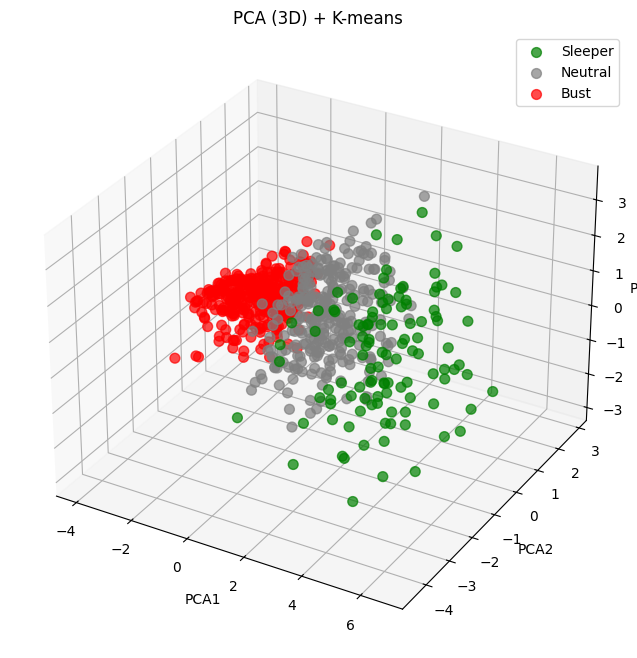

In [9]:
# three sleeper outliers to hide in the plot only
hide_players = ["Michael Porter Jr.", "Nic Claxton", "Keldon Johnson"]

# remove them only from the plotting dataframe
df_cluster_plot = df_cluster[~df_cluster["PLAYER_NAME"].isin(hide_players)].copy()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

colors = {"Sleeper": "green", "Neutral": "gray", "Bust": "red"}

for label in ["Sleeper", "Neutral", "Bust"]:
    temp = df_cluster_plot[df_cluster_plot["pca_label"] == label]
    ax.scatter(
        temp["PCA1"], temp["PCA2"], temp["PCA3"],
        label=label,
        s=50,
        alpha=0.7,
        c=colors[label]
    )

ax.set_title("PCA (3D) + K-means")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.legend()
plt.show()

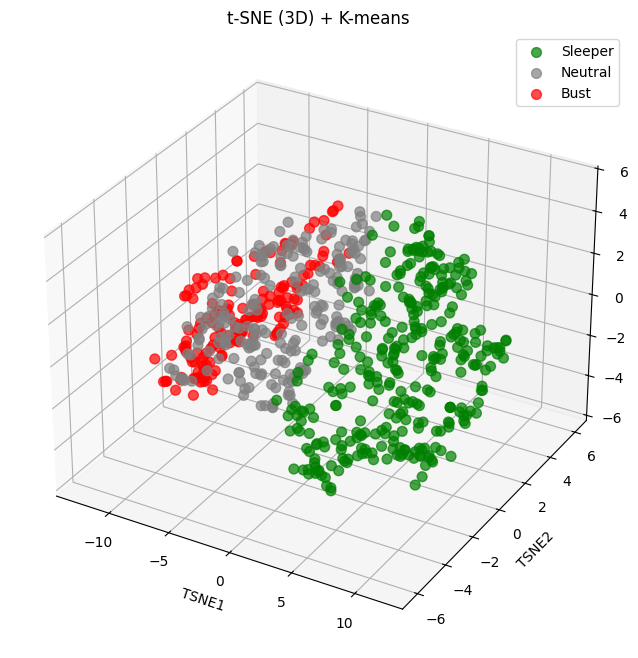

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for label in ["Sleeper", "Neutral", "Bust"]:
    temp = df_cluster[df_cluster["tsne_label"] == label]
    ax.scatter(
        temp["TSNE1"], temp["TSNE2"], temp["TSNE3"],
        label=label,
        s=50,
        alpha=0.7,
        c=colors[label]
    )

ax.set_title("t-SNE (3D) + K-means")
ax.set_xlabel("TSNE1")
ax.set_ylabel("TSNE2")
ax.set_zlabel("TSNE3")
ax.legend()
plt.show()

These results suggest that the PCA + K-means solution is the more conservative and stable grouping, while the t-SNE + K-means solution is more aggressive in separating players into an upper-outcome group. The PCA step itself worked well in a technical sense, because the first three principal components explain about 93.64% of the total variation, which means the reduced 3-dimensional PCA space still preserves most of the original information. Under this PCA-based clustering, the sample is split into 279 Bust, 259 Neutral, and 136 Sleeper, so the Sleeper group is much smaller and looks like a stricter, more selective cluster.

By contrast, the t-SNE + K-means result produces 269 Sleeper, 213 Neutral, and 192 Bust, which is a much more balanced but also much more optimistic partition. The cross-table shows that the main disagreement comes from the players labeled Neutral by PCA: under t-SNE, these 259 players are split into 129 still Neutral and 130 moved to Sleeper, with none moved to Bust. That means t-SNE is mainly reclassifying a large part of the PCA middle group upward into Sleeper. At the same time, the PCA Sleeper group is perfectly preserved by t-SNE, and the PCA Bust group is mostly preserved as Bust, although 84 of those PCA Bust players are softened into Neutral by t-SNE. So overall, both methods agree strongly on the clearest Sleeper cases and many of the clearest Bust cases, but t-SNE is much more likely to pull borderline players out of Neutral or Bust and move them upward.

I would interpret this as follows: PCA + K-means gives a stricter and more cautious classification, which is usually easier to defend if final Sleeper label to represent only the strongest positive-outcome cases. t-SNE + K-means gives a more expanded Sleeper group, which may be useful for exploration, but it is probably less conservative and less stable as a final classification rule. So if PCA + K-means is likely the safer choice, while t-SNE is better treated as a supporting visualization or sensitivity check.

## Saving Clsutering Result

In [11]:
# -------------------------------------------------
# set this manually one time
# -------------------------------------------------

OUTPUT_DIR = PROJECT_ROOT / "src" / "Player_Performance_Clustering"/ "Result"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# build t-SNE summary objects
# -------------------------------------------------
tsne_summary = (
    df_cluster.groupby("tsne_label")[cluster_features]
    .mean()
    .round(3)
)

tsne_counts_df = (
    df_cluster["tsne_label"]
    .value_counts()
    .rename_axis("tsne_label")
    .reset_index(name="count")
)

tsne_silhouette = silhouette_score(X_tsne, df_cluster["tsne_cluster"])

# -------------------------------------------------
# save main full clustering table
# -------------------------------------------------
df_cluster.to_csv(OUTPUT_DIR / "clustering_all_results.csv", index=False)

# -------------------------------------------------
# save PCA plot df
# -------------------------------------------------

pca_plot_cols = [
    "PLAYER_ID", "PLAYER_NAME",
    "PCA1", "PCA2", "PCA3",
    "pca_cluster", "pca_label",
    "expected_score", "realized_score", "delta_score"
]
df_cluster_plot[pca_plot_cols].to_csv(OUTPUT_DIR / "pca_plot_df.csv", index=False)

# -------------------------------------------------
# save t-SNE plot df
# -------------------------------------------------
tsne_plot_cols = [
    "PLAYER_ID", "PLAYER_NAME",
    "TSNE1", "TSNE2", "TSNE3",
    "tsne_cluster", "tsne_label",
    "expected_score", "realized_score", "delta_score"
]
df_cluster[tsne_plot_cols].to_csv(OUTPUT_DIR / "tsne_plot_df.csv", index=False)

# -------------------------------------------------
# save PCA summary and counts
# -------------------------------------------------
pca_summary.to_csv(OUTPUT_DIR / "pca_summary.csv")

pca_counts_df = (
    pca_counts.rename_axis("pca_label")
    .reset_index(name="count")
)
pca_counts_df.to_csv(OUTPUT_DIR / "pca_counts.csv", index=False)

# -------------------------------------------------
# save PCA metrics
# -------------------------------------------------
pca_metrics = pd.DataFrame({
    "metric": [
        "explained_variance_ratio_pc1",
        "explained_variance_ratio_pc2",
        "explained_variance_ratio_pc3",
        "total_explained_variance",
        "silhouette_score"
    ],
    "value": [
        pca.explained_variance_ratio_[0],
        pca.explained_variance_ratio_[1],
        pca.explained_variance_ratio_[2],
        pca.explained_variance_ratio_.sum(),
        pca_silhouette
    ]
})
pca_metrics.to_csv(OUTPUT_DIR / "pca_metrics.csv", index=False)

# -------------------------------------------------
# save t-SNE summary and counts
# -------------------------------------------------
tsne_summary.to_csv(OUTPUT_DIR / "tsne_summary.csv")
tsne_counts_df.to_csv(OUTPUT_DIR / "tsne_counts.csv", index=False)

# -------------------------------------------------
# save t-SNE metrics
# -------------------------------------------------
tsne_metrics = pd.DataFrame({
    "metric": ["silhouette_score"],
    "value": [tsne_silhouette]
})
tsne_metrics.to_csv(OUTPUT_DIR / "tsne_metrics.csv", index=False)

# -------------------------------------------------
# save merged player table
# -------------------------------------------------
player_analysis_compare.to_csv(
    OUTPUT_DIR / "player_analysis_compare_with_labels.csv",
    index=False
)

print("All clustering outputs saved.")


All clustering outputs saved.



## Multionmoial Logistic regression

**The purpose of the multinomial logistic regression is to predict a player’s final outcome class: Bust/Neutral/Sleeper** using only the player’s early-career information.

**The input to the model was the player’s first 4-season profile, summarized from the cleaned season-level data.** Rather than using only one simple average, the predictors included several types of early-career features derived from Years 1–4, such as:

1. 4-year averages (for example, average points, assists, rebounds, shooting percentages, and performance score over Years 1–4),
2. Year 4 values,
3. improvement from Year 1 to Year 4, and
4. slopes across Years 1–4.

So, each player was represented by one row of early-career features.

**The output variable was the final cluster label from the PCA + K-means step:Bust/Neutral/Sleeper**

These labels were not assigned manually. They were created earlier by:

1. building a player-level table using Years 1–4 and Years 5–7 information,
2. summarizing expected and realized performance,
3. reducing the combined outcome space with PCA, and
4. grouping players with K-means into three clusters, which were then interpreted as Bust, Neutral, and Sleeper based on their outcome patterns.

**So multinomial logistic regression is learning to predict the historically constructed class label.**


The multinomial logistic regression does not only give one final label. It first calculates a score for each class: Bust Neutral Sleeper using the input features and the learned coefficients.

**Then it converts those scores into probabilities using the softmax function, so the three probabilities:**

prob_Bust/prob_Neutral/prob_Sleeperwill always be between 0 and 1 add up to 1.

**Then the model picks the class with the largest probability as the final predicted class.**

In [12]:
# =========================================================
# 1. Start from final player-level dataframe
# =========================================================
df_logit = player_analysis_compare.copy()

# Keep only rows with a valid PCA label
df_logit = df_logit.dropna(subset=["pca_label"]).copy()

# =========================================================
# 2. Make sure PLAYER_ID exists
# =========================================================
if "PLAYER_ID" not in df_logit.columns:
    player_id_lookup = (
        df_clean[["PLAYER_NAME", "PLAYER_ID"]]
        .dropna()
        .drop_duplicates()
        .groupby("PLAYER_NAME", as_index=False)["PLAYER_ID"]
        .agg(lambda x: x.value_counts().idxmax())
    )

    df_logit = df_logit.merge(
        player_id_lookup,
        on="PLAYER_NAME",
        how="left"
    )

df_logit["PLAYER_ID"] = pd.to_numeric(df_logit["PLAYER_ID"], errors="coerce")

# =========================================================
# 3. Read fixed split file and attach SPLIT
# =========================================================
split_df = pd.read_csv(DATA_DIR / "player_train_test_split_with_score.csv").copy()

split_df["PLAYER_ID"] = pd.to_numeric(split_df["PLAYER_ID"], errors="coerce")

split_player = split_df[["PLAYER_ID", "SPLIT"]].drop_duplicates().copy()

df_logit = df_logit.merge(
    split_player,
    on="PLAYER_ID",
    how="left"
)

# keep only rows with valid split
df_logit = df_logit.dropna(subset=["SPLIT"]).copy()

# =========================================================
# 4. Build input X using ONLY Years 1-4 features
# =========================================================
x_cols = [
    col for col in df_logit.columns
    if (
        col.endswith("_1to4_avg")
        or col.endswith("_year4")
        or col.endswith("_improve_y1_to_y4")
        or col.endswith("_slope_1to4")
    )
]

# Remove anything that should not be used as predictor
remove_cols = [
    "performance_score_5to7_avg",
    "performance_score_5to7_total",
    "expected_score",
    "realized_score",
    "delta_score"
]
x_cols = [col for col in x_cols if col not in remove_cols]

# Define X and y
X = df_logit[x_cols].copy()
y = df_logit["pca_label"].copy()

print("Input feature count:", len(x_cols))
print("First 10 input columns:", x_cols[:10])

# =========================================================
# 5. Fixed train / test split using uploaded csv
# =========================================================
train_mask = df_logit["SPLIT"] == "Train"
test_mask = df_logit["SPLIT"] == "Test"

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# =========================================================
# 6. Multinomial logistic regression pipeline
# =========================================================
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        random_state=42
    ))
])

# Fit model on TRAIN only
logit_model.fit(X_train, y_train)

# =========================================================
# 7. Predictions on TEST set
# =========================================================
y_pred_test = logit_model.predict(X_test)
y_prob_test = logit_model.predict_proba(X_test)

# =========================================================
# 8. Accuracy and confusion matrix on TEST set
# =========================================================
acc = accuracy_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test, labels=["Bust", "Neutral", "Sleeper"])

print("\n==========================================")
print("Multinomial Logistic Regression Results")
print("==========================================")
print("Accuracy:", round(acc, 4))

print("\nConfusion Matrix (rows = actual, columns = predicted)")
cm_df = pd.DataFrame(
    cm,
    index=["Actual_Bust", "Actual_Neutral", "Actual_Sleeper"],
    columns=["Pred_Bust", "Pred_Neutral", "Pred_Sleeper"]
)
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

# =========================================================
# 9. Probability class for each player in TEST set
# =========================================================
class_names = logit_model.named_steps["clf"].classes_

prob_df_test = pd.DataFrame(
    y_prob_test,
    columns=[f"prob_{c}" for c in class_names],
    index=X_test.index
)

player_probabilities_test = df_logit.loc[X_test.index, ["PLAYER_NAME", "PLAYER_ID"]].copy()
player_probabilities_test["actual_class"] = y_test
player_probabilities_test["predicted_class"] = y_pred_test
player_probabilities_test = pd.concat([player_probabilities_test, prob_df_test], axis=1)

print("\nTest-set player probabilities preview:")
print(player_probabilities_test.head(10))

# =========================================================
# 10. Probability class for ALL players
# =========================================================
all_pred = logit_model.predict(X)
all_prob = logit_model.predict_proba(X)

all_prob_df = pd.DataFrame(
    all_prob,
    columns=[f"prob_{c}" for c in class_names],
    index=X.index
)

player_probabilities = df_logit[["PLAYER_NAME", "PLAYER_ID"]].copy()
player_probabilities["actual_class"] = y
player_probabilities["predicted_class"] = all_pred
player_probabilities = pd.concat([player_probabilities, all_prob_df], axis=1)

# optional: full-sample accuracy / confusion matrix
acc_full = accuracy_score(y, all_pred)
cm_full = confusion_matrix(y, all_pred, labels=["Bust", "Neutral", "Sleeper"])

cm_df_full = pd.DataFrame(
    cm_full,
    index=["Actual_Bust", "Actual_Neutral", "Actual_Sleeper"],
    columns=["Pred_Bust", "Pred_Neutral", "Pred_Sleeper"]
)

print("\n==========================================")
print("Full-sample fitted results")
print("==========================================")
print("Accuracy:", round(acc_full, 4))
print(cm_df_full)

Input feature count: 48
First 10 input columns: ['AST_1to4_avg', 'AST_improve_y1_to_y4', 'AST_slope_1to4', 'AST_year4', 'BLK_1to4_avg', 'BLK_improve_y1_to_y4', 'BLK_slope_1to4', 'BLK_year4', 'FG3_PCT_1to4_avg', 'FG3_PCT_improve_y1_to_y4']

Train size: 360
Test size: 145

Multinomial Logistic Regression Results
Accuracy: 0.6276

Confusion Matrix (rows = actual, columns = predicted)
                Pred_Bust  Pred_Neutral  Pred_Sleeper
Actual_Bust            53            21             1
Actual_Neutral         16            31             8
Actual_Sleeper          1             7             7

Classification Report:
              precision    recall  f1-score   support

        Bust     0.7571    0.7067    0.7310        75
     Neutral     0.5254    0.5636    0.5439        55
     Sleeper     0.4375    0.4667    0.4516        15

    accuracy                         0.6276       145
   macro avg     0.5734    0.5790    0.5755       145
weighted avg     0.6362    0.6276    0.6311       


## LSTM Model

Next, let us try to use the LSTM model to train the data and comapre the result with pervious model.

The LSTM will use:

- Cleaned season-level player statistics
- Data from only the first 4 seasons
- Approximately 23 features per season

For prediction:

- Bust / Neutral / Sleeper

These labels are derived from previous PCA + K-means clustering analysis.The model is trained using a fixed player split from player_train_test_split_with_score.csv, evaluated on the test set, and then used to generate final predictions for all eligible players.

**The goal is to test whether the season-by-season development pattern can predict players better than a simple logistic regression baseline model.**

In [13]:
SEED = 620

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

set_seed(SEED)

torch_gen = torch.Generator()
torch_gen.manual_seed(SEED)

In [14]:
# =========================================================
# 1. Read fixed split file
# =========================================================
split_df = pd.read_csv(DATA_DIR / "player_train_test_split_with_score.csv").copy()
split_df["PLAYER_ID"] = pd.to_numeric(split_df["PLAYER_ID"], errors="coerce")

# one row per player
split_player = split_df[["PLAYER_ID", "PLAYER_NAME", "SPLIT"]].drop_duplicates(subset=["PLAYER_ID"]).copy()

# =========================================================
# 2. Prepare season-level sequence data
#    IMPORTANT: use PLAYER_ID as the main key
# =========================================================
df_seq = df_clean.copy()
df_seq["PLAYER_ID"] = pd.to_numeric(df_seq["PLAYER_ID"], errors="coerce")

# sort by PLAYER_ID, not PLAYER_NAME
df_seq = df_seq.sort_values(["PLAYER_ID", "year"]).reset_index(drop=True)

# assign career order after cleaning
df_seq["career_year"] = df_seq.groupby("PLAYER_ID").cumcount() + 1

# keep only first 4 cleaned seasons for sequence input
df_seq_1to4 = df_seq[df_seq["career_year"].between(1, 4)].copy()

# keep only players who have exactly 4 cleaned seasons in the input block
valid_players_1to4 = (
    df_seq_1to4.groupby("PLAYER_ID")
    .size()
    .reset_index(name="n_rows")
)

valid_players_1to4 = valid_players_1to4.loc[
    valid_players_1to4["n_rows"] == 4, "PLAYER_ID"
]

df_seq_1to4 = df_seq_1to4[df_seq_1to4["PLAYER_ID"].isin(valid_players_1to4)].copy()

# =========================================================
# 3. Merge target labels using PLAYER_ID
# =========================================================
label_lookup = player_analysis_compare[["PLAYER_ID", "pca_label"]].drop_duplicates().copy()
label_lookup["PLAYER_ID"] = pd.to_numeric(label_lookup["PLAYER_ID"], errors="coerce")

df_lstm = df_seq_1to4.merge(
    label_lookup,
    on="PLAYER_ID",
    how="inner"
).copy()

# attach fixed split by PLAYER_ID
df_lstm = df_lstm.merge(
    split_player[["PLAYER_ID", "SPLIT"]],
    on="PLAYER_ID",
    how="left"
)

# keep only players with a defined split
df_lstm = df_lstm.dropna(subset=["SPLIT", "pca_label"]).copy()

# =========================================================
# 4. Define input features for each season
# =========================================================
seq_features = [
    "GP", "GS", "MIN",
    "FGM", "FGA", "FG_PCT",
    "FG3M", "FG3A", "FG3_PCT",
    "FTM", "FTA", "FT_PCT",
    "OREB", "DREB", "REB",
    "AST", "TOV", "STL", "BLK", "PF", "PTS",
    "PLUS_MINUS", "PFD", "performance_score"
]

seq_features = [c for c in seq_features if c in df_lstm.columns]

print("LSTM sequence input features:")
print(seq_features)

# =========================================================
# 5. Build one sequence per player using PLAYER_ID
# =========================================================
player_names = []
player_ids = []
player_splits = []
X_seq = []
y_labels = []

for player_id, g in df_lstm.groupby("PLAYER_ID"):
    g = g.sort_values("career_year")

    if len(g) == 4:
        X_seq.append(g[seq_features].values.astype(np.float32))
        y_labels.append(g["pca_label"].iloc[0])
        player_ids.append(player_id)

        # keep one player name just for display
        player_names.append(g["PLAYER_NAME"].iloc[0] if "PLAYER_NAME" in g.columns else str(player_id))
        player_splits.append(g["SPLIT"].iloc[0])

X_seq = np.array(X_seq, dtype=np.float32)
y_labels = np.array(y_labels)
player_ids = np.array(player_ids)
player_splits = np.array(player_splits)

print("Sequence tensor shape:", X_seq.shape)
print("Number of players:", len(player_ids))

# =========================================================
# 6. Encode labels
# =========================================================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

# =========================================================
# 7. Fixed train / test split from CSV
# =========================================================
train_idx = np.where(player_splits == "Train")[0]
test_idx = np.where(player_splits == "Test")[0]

X_train = X_seq[train_idx]
X_test = X_seq[test_idx]
y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

player_train = np.array(player_names)[train_idx]
player_test = np.array(player_names)[test_idx]
player_id_train = player_ids[train_idx]
player_id_test = player_ids[test_idx]

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Unique TEST PLAYER_ID actually used:", len(np.unique(player_id_test)))

# =========================================================
# 8. Audit missing TEST players BEFORE training
# =========================================================
csv_test_ids = set(
    split_player.loc[split_player["SPLIT"] == "Test", "PLAYER_ID"].dropna().astype(int)
)
used_test_ids = set(pd.Series(player_id_test).dropna().astype(int))

missing_test_ids = csv_test_ids - used_test_ids

print("\nCSV TEST PLAYER_ID count:", len(csv_test_ids))
print("Used TEST PLAYER_ID count:", len(used_test_ids))
print("Still missing TEST PLAYER_ID:", len(missing_test_ids))

if len(missing_test_ids) > 0:
    print("\nMissing TEST players:")
    print(
        split_player.loc[
            split_player["PLAYER_ID"].astype(int).isin(missing_test_ids),
            ["PLAYER_ID", "PLAYER_NAME", "SPLIT"]
        ].drop_duplicates()
    )

# =========================================================
# 9. Standardize features using training data only
# =========================================================
n_train, seq_len, n_features = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, seq_len, n_features)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape[0], seq_len, n_features)

# =========================================================
# 10. PyTorch dataset
# =========================================================
class PlayerSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = PlayerSequenceDataset(X_train_scaled, y_train)
test_dataset = PlayerSequenceDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=torch_gen)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# =========================================================
# 11. Define LSTM model
# =========================================================
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMClassifier(
    input_size=n_features,
    hidden_size=32,
    num_layers=1,
    num_classes=len(label_encoder.classes_),
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# =========================================================
# 12. Train LSTM
# =========================================================
n_epochs = 80

for epoch in range(n_epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_loader.dataset)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {avg_loss:.4f}")

# =========================================================
# 13. TEST-set evaluation
# =========================================================
model.eval()

test_probs = []
test_preds = []
test_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        test_probs.append(probs)
        test_preds.append(preds)
        test_true.append(yb.numpy())

test_probs = np.vstack(test_probs)
test_preds = np.concatenate(test_preds)
test_true = np.concatenate(test_true)

y_test_labels = label_encoder.inverse_transform(test_true)
y_pred_test_labels = label_encoder.inverse_transform(test_preds)

lstm_acc = accuracy_score(y_test_labels, y_pred_test_labels)

lstm_cm = confusion_matrix(
    y_test_labels,
    y_pred_test_labels,
    labels=["Bust", "Neutral", "Sleeper"]
)

lstm_cm_df = pd.DataFrame(
    lstm_cm,
    index=["Actual_Bust", "Actual_Neutral", "Actual_Sleeper"],
    columns=["Pred_Bust", "Pred_Neutral", "Pred_Sleeper"]
)

print("\n==========================================")
print("LSTM Classification Results (Test Set)")
print("==========================================")
print("Accuracy:", round(lstm_acc, 4))

print("\nConfusion Matrix (rows = actual, columns = predicted)")
print(lstm_cm_df)

print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_test_labels, digits=4))

LSTM sequence input features:
['GP', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'PTS', 'PLUS_MINUS', 'PFD', 'performance_score']
Sequence tensor shape: (505, 4, 23)
Number of players: 505
Class mapping:
0 -> Bust
1 -> Neutral
2 -> Sleeper

Train size: 360
Test size: 145
Unique TEST PLAYER_ID actually used: 145

CSV TEST PLAYER_ID count: 145
Used TEST PLAYER_ID count: 145
Still missing TEST PLAYER_ID: 0
Epoch 1/80 - Train Loss: 1.0732
Epoch 10/80 - Train Loss: 0.7209
Epoch 20/80 - Train Loss: 0.6081
Epoch 30/80 - Train Loss: 0.5654
Epoch 40/80 - Train Loss: 0.5017
Epoch 50/80 - Train Loss: 0.4646
Epoch 60/80 - Train Loss: 0.4094
Epoch 70/80 - Train Loss: 0.3617
Epoch 80/80 - Train Loss: 0.3140

LSTM Classification Results (Test Set)
Accuracy: 0.6345

Confusion Matrix (rows = actual, columns = predicted)
                Pred_Bust  Pred_Neutral  Pred_Sleeper
Actual_Bust            55           

In [15]:
# =========================================================
# Build LSTM test-set result table
# =========================================================
prob_cols = [f"prob_{cls}" for cls in label_encoder.classes_]

lstm_test_results = pd.DataFrame({
    "PLAYER_NAME": player_test,
    "PLAYER_ID": player_id_test,
    "actual_class": y_test_labels,
    "predicted_class": y_pred_test_labels
})

lstm_prob_df_test = pd.DataFrame(test_probs, columns=prob_cols)

lstm_test_results = pd.concat(
    [lstm_test_results.reset_index(drop=True), lstm_prob_df_test.reset_index(drop=True)],
    axis=1
)

# Analysis

Next, analysis the difference bewtween logistic and lstm network

In [16]:

# =========================================================
# 1. Accuracy comparison on TEST dataset
# =========================================================
comparison_metrics = pd.DataFrame({
    "model": ["Logistic Regression", "LSTM"],
    "accuracy_test_sample": [acc, lstm_acc]
})

print("==========================================")
print("Model Accuracy Comparison (Test Dataset)")
print("==========================================")
print(comparison_metrics)

# =========================================================
# 2. Show confusion matrices on TEST dataset
# =========================================================
print("\n==========================================")
print("Logistic Regression Confusion Matrix (Test Dataset)")
print("==========================================")
print(cm_df)

print("\n==========================================")
print("LSTM Confusion Matrix (Test Dataset)")
print("==========================================")
print(lstm_cm_df)

# =========================================================
# 3. Merge player-level TEST predictions for direct comparison
# =========================================================
# logistic test-set predictions
logit_compare = player_probabilities_test.copy().rename(columns={
    "actual_class": "actual_class_logit",
    "predicted_class": "predicted_class_logit"
})

# lstm test-set predictions
lstm_compare = lstm_test_results.copy().rename(columns={
    "actual_class": "actual_class_lstm",
    "predicted_class": "predicted_class_lstm"
})

# merge by PLAYER_ID if available, otherwise by PLAYER_NAME
merge_keys = ["PLAYER_ID"] if ("PLAYER_ID" in logit_compare.columns and "PLAYER_ID" in lstm_compare.columns) else ["PLAYER_NAME"]

player_compare = logit_compare.merge(
    lstm_compare,
    on=merge_keys,
    how="inner",
    suffixes=("_logit", "_lstm")
)

# keep one common actual class column
if "actual_class_logit" in player_compare.columns:
    player_compare["actual_class"] = player_compare["actual_class_logit"]

print("\n==========================================")
print("Player-level Comparison Preview (Test Dataset)")
print("==========================================")
print(player_compare.head(10))

# =========================================================
# 4. Compare TEST-set predictions directly
# =========================================================
same_prediction_rate = (
    player_compare["predicted_class_logit"] == player_compare["predicted_class_lstm"]
).mean()

logit_correct_rate = (
    player_compare["predicted_class_logit"] == player_compare["actual_class"]
).mean()

lstm_correct_rate = (
    player_compare["predicted_class_lstm"] == player_compare["actual_class"]
).mean()

comparison_summary = pd.DataFrame({
    "metric": [
        "same_prediction_rate_between_models_test_set",
        "logit_accuracy_test_set_on_common_players",
        "lstm_accuracy_test_set_on_common_players"
    ],
    "value": [
        same_prediction_rate,
        logit_correct_rate,
        lstm_correct_rate
    ]
})

print("\n==========================================")
print("Direct Comparison on Test Dataset")
print("==========================================")
print(comparison_summary)

# =========================================================
# 5. Confusion matrix between the TWO MODELS on TEST set
# =========================================================
model_vs_model_cm = pd.crosstab(
    player_compare["predicted_class_logit"],
    player_compare["predicted_class_lstm"],
    rownames=["Logit_Pred"],
    colnames=["LSTM_Pred"]
)

print("\n==========================================")
print("Cross-model Confusion Matrix (Test Dataset)")
print("==========================================")
print(model_vs_model_cm)

Model Accuracy Comparison (Test Dataset)
                 model  accuracy_test_sample
0  Logistic Regression              0.627586
1                 LSTM              0.634483

Logistic Regression Confusion Matrix (Test Dataset)
                Pred_Bust  Pred_Neutral  Pred_Sleeper
Actual_Bust            53            21             1
Actual_Neutral         16            31             8
Actual_Sleeper          1             7             7

LSTM Confusion Matrix (Test Dataset)
                Pred_Bust  Pred_Neutral  Pred_Sleeper
Actual_Bust            55            17             3
Actual_Neutral         17            30             8
Actual_Sleeper          3             5             7

Player-level Comparison Preview (Test Dataset)
  PLAYER_NAME_logit  PLAYER_ID actual_class_logit predicted_class_logit  \
0   Jonathan Bender       1886               Bust                  Bust   
1    Stromile Swift       2031               Bust               Neutral   
2     Primoz Brezec       20

In [17]:
VIS_DIR = PROJECT_ROOT / "src" / "Player_Performance_Clustering" / "Result"
VIS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("VIS_DIR:", VIS_DIR)

# =========================================================
# 1. Accuracy comparison on TEST dataset
# =========================================================
comparison_metrics = pd.DataFrame({
    "model": ["Logistic Regression", "LSTM"],
    "accuracy_test_sample": [acc, lstm_acc]
})

# =========================================================
# 2. Merge player-level TEST predictions for direct comparison
# =========================================================
logit_compare = player_probabilities_test.copy().rename(columns={
    "actual_class": "actual_class_logit",
    "predicted_class": "predicted_class_logit"
})

lstm_compare = lstm_test_results.copy().rename(columns={
    "actual_class": "actual_class_lstm",
    "predicted_class": "predicted_class_lstm"
})

merge_keys = ["PLAYER_ID"] if (
    "PLAYER_ID" in logit_compare.columns and "PLAYER_ID" in lstm_compare.columns
) else ["PLAYER_NAME"]

player_compare = logit_compare.merge(
    lstm_compare,
    on=merge_keys,
    how="inner",
    suffixes=("_logit", "_lstm")
)

if "actual_class_logit" in player_compare.columns:
    player_compare["actual_class"] = player_compare["actual_class_logit"]

# =========================================================
# 3. Direct comparison summary
# =========================================================
same_prediction_rate = (
    player_compare["predicted_class_logit"] == player_compare["predicted_class_lstm"]
).mean()

logit_correct_rate = (
    player_compare["predicted_class_logit"] == player_compare["actual_class"]
).mean()

lstm_correct_rate = (
    player_compare["predicted_class_lstm"] == player_compare["actual_class"]
).mean()

comparison_summary = pd.DataFrame({
    "metric": [
        "same_prediction_rate_between_models_test_set",
        "logit_accuracy_test_set_on_common_players",
        "lstm_accuracy_test_set_on_common_players"
    ],
    "value": [
        same_prediction_rate,
        logit_correct_rate,
        lstm_correct_rate
    ]
})

# =========================================================
# 4. Cross-model confusion matrix
# =========================================================
model_vs_model_cm = pd.crosstab(
    player_compare["predicted_class_logit"],
    player_compare["predicted_class_lstm"],
    rownames=["Logit_Pred"],
    colnames=["LSTM_Pred"]
)

# =========================================================
# 5. Save all result tables
# =========================================================
comparison_metrics.to_csv(VIS_DIR / "comparison_metrics.csv", index=False)

cm_df.to_csv(VIS_DIR / "logit_confusion_matrix_test.csv")
lstm_cm_df.to_csv(VIS_DIR / "lstm_confusion_matrix_test.csv")

player_probabilities_test.to_csv(VIS_DIR / "logit_test_predictions.csv", index=False)
lstm_test_results.to_csv(VIS_DIR / "lstm_test_predictions.csv", index=False)

player_compare.to_csv(VIS_DIR / "player_compare_test.csv", index=False)
comparison_summary.to_csv(VIS_DIR / "comparison_summary_test.csv", index=False)
model_vs_model_cm.to_csv(VIS_DIR / "cross_model_confusion_matrix_test.csv")

print("All logistic regression and LSTM result tables saved.")

PROJECT_ROOT: C:\Users\27946\OneDrive\桌面\Git Clone\STAT-946-Case-Study-3
VIS_DIR: C:\Users\27946\OneDrive\桌面\Git Clone\STAT-946-Case-Study-3\src\Player_Performance_Clustering\Result
All logistic regression and LSTM result tables saved.


## Risk

**Next, we need discuss about the risks may happen in datasets.**

1. Find the largest probability

In each model, we used:
max_probability=max(prob_Bust,prob_Neutral,prob_Sleeper)

This take the class the model is most confident about.

2. Convert that into a confidence / risk label

Thresholds:
High if max_probability >= 0.70
Medium if 0.55 <= max_probability < 0.70
Low if max_probability < 0.55

We measured prediction confidence using the largest class probability produced by the LSTM model. For each player, the model outputs probabilities for Bust, Neutral, and Sleeper, and the maximum of these three values was used as the confidence score. We then converted this score into a simple confidence tier: High (≥ 0.70), Medium (0.55–0.69), and Low (< 0.55). In decision terms, low-confidence cases represent higher-risk classifications, while high-confidence cases represent more stable model signals.


In [18]:
# =========================================================
# 1. Read split file and prepare player split lookup
# =========================================================
split_df = pd.read_csv(DATA_DIR / "player_train_test_split_with_score.csv").copy()

split_df["PLAYER_ID"] = pd.to_numeric(split_df["PLAYER_ID"], errors="coerce")

split_lookup = (
    split_df[["PLAYER_ID", "SPLIT"]]
    .dropna(subset=["PLAYER_ID"])
    .drop_duplicates(subset=["PLAYER_ID"])
    .copy()
    .rename(columns={"SPLIT": "Train_Test"})
)

# =========================================================
# 2. Build one prediction pool: all players with >= 4 usable seasons
# =========================================================
df_pred = df_clean.copy()
df_pred["PLAYER_ID"] = pd.to_numeric(df_pred["PLAYER_ID"], errors="coerce")

# sort by PLAYER_ID, not PLAYER_NAME
df_pred = df_pred.sort_values(["PLAYER_ID", "year"]).reset_index(drop=True)

# career order after cleaning
df_pred["career_year"] = df_pred.groupby("PLAYER_ID").cumcount() + 1

# keep only first 4 cleaned seasons
df_pred_1to4 = df_pred[df_pred["career_year"].between(1, 4)].copy()

# keep only players with exactly 4 rows in the 1-4 block
valid_players_pred = (
    df_pred_1to4.groupby("PLAYER_ID")
    .size()
    .reset_index(name="n_rows")
)
valid_players_pred = valid_players_pred.loc[
    valid_players_pred["n_rows"] == 4, "PLAYER_ID"
]

df_pred_1to4 = df_pred_1to4[df_pred_1to4["PLAYER_ID"].isin(valid_players_pred)].copy()

# =========================================================
# 3. Build LSTM sequence tensor for all eligible players
# =========================================================
# seq_features must be the SAME feature list used to train the LSTM
pred_player_names = []
pred_player_ids = []
X_pred_seq = []

for player_id, g in df_pred_1to4.groupby("PLAYER_ID"):
    g = g.sort_values("career_year")
    if len(g) == 4:
        X_pred_seq.append(g[seq_features].values.astype(np.float32))
        pred_player_ids.append(player_id)

        # keep one display name
        if "PLAYER_NAME" in g.columns:
            pred_player_names.append(g["PLAYER_NAME"].iloc[0])
        else:
            pred_player_names.append(str(player_id))

X_pred_seq = np.array(X_pred_seq, dtype=np.float32)

print("Prediction tensor shape:", X_pred_seq.shape)
print("Players to score:", len(pred_player_ids))

# =========================================================
# 4. Scale with the SAME scaler used in LSTM training
# =========================================================
X_pred_scaled = scaler.transform(
    X_pred_seq.reshape(-1, n_features)
).reshape(X_pred_seq.shape[0], seq_len, n_features)

# dummy labels just to use the same Dataset class
dummy_y = np.zeros(X_pred_scaled.shape[0], dtype=int)

pred_dataset = PlayerSequenceDataset(X_pred_scaled, dummy_y)
pred_loader = DataLoader(pred_dataset, batch_size=32, shuffle=False)

# =========================================================
# 5. Predict with trained LSTM
# =========================================================
model.eval()

pred_probs = []
pred_classes_idx = []

with torch.no_grad():
    for xb, _ in pred_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        pred_probs.append(probs)
        pred_classes_idx.append(preds)

pred_probs = np.vstack(pred_probs)
pred_classes_idx = np.concatenate(pred_classes_idx)
pred_classes = label_encoder.inverse_transform(pred_classes_idx)

# =========================================================
# 6. Attach actual label if available
#    Use PLAYER_ID from player_analysis_compare
# =========================================================
actual_lookup = (
    player_analysis_compare[["PLAYER_ID", "pca_label"]]
    .dropna(subset=["PLAYER_ID"])
    .drop_duplicates(subset=["PLAYER_ID"])
    .copy()
    .rename(columns={"pca_label": "actual_class"})
)
actual_lookup["PLAYER_ID"] = pd.to_numeric(actual_lookup["PLAYER_ID"], errors="coerce")

# =========================================================
# 7. Build one final result table
# =========================================================
prob_cols = [f"prob_{cls}" for cls in label_encoder.classes_]
prob_df = pd.DataFrame(pred_probs, columns=prob_cols)

final_lstm_predictions = pd.DataFrame({
    "PLAYER_NAME": pred_player_names,
    "PLAYER_ID": pred_player_ids,
    "predicted_class": pred_classes
})

final_lstm_predictions = pd.concat(
    [final_lstm_predictions.reset_index(drop=True), prob_df.reset_index(drop=True)],
    axis=1
)

# merge actual class if known
final_lstm_predictions = final_lstm_predictions.merge(
    actual_lookup,
    on="PLAYER_ID",
    how="left"
)

# merge train/test membership
final_lstm_predictions = final_lstm_predictions.merge(
    split_lookup,
    on="PLAYER_ID",
    how="left"
)

# fill players not previously in split file
final_lstm_predictions["Train_Test"] = final_lstm_predictions["Train_Test"].fillna("None")

# flag whether actual label exists
final_lstm_predictions["label_known"] = final_lstm_predictions["actual_class"].notna().astype(int)

# mark whether prediction matches actual, only when actual exists
final_lstm_predictions["is_correct"] = np.where(
    final_lstm_predictions["label_known"] == 1,
    (final_lstm_predictions["predicted_class"] == final_lstm_predictions["actual_class"]).astype(int),
    np.nan
)

# max class probability
final_lstm_predictions["max_pred_prob"] = final_lstm_predictions[prob_cols].max(axis=1)

# confidence band
final_lstm_predictions["confidence"] = np.select(
    [
        final_lstm_predictions["max_pred_prob"] >= 0.70,
        (final_lstm_predictions["max_pred_prob"] >= 0.55) & (final_lstm_predictions["max_pred_prob"] < 0.70),
        final_lstm_predictions["max_pred_prob"] < 0.55
    ],
    [
        "High",
        "Medium",
        "Low"
    ],
    default="Low"
)

# optional: keep only final useful columns
final_cols = [
    "PLAYER_NAME",
    "PLAYER_ID",
    "Train_Test",
    "actual_class",
    "predicted_class",
    "prob_Bust",
    "prob_Neutral",
    "prob_Sleeper",
    "label_known",
    "is_correct",
    "max_pred_prob",
    "confidence"
]

final_cols = [c for c in final_cols if c in final_lstm_predictions.columns]
final_lstm_predictions = final_lstm_predictions[final_cols].copy()

# sort:
# known labels first, then Test, then Train, then None, then highest confidence
train_test_order = {"Test": 0, "Train": 1, "None": 2}
final_lstm_predictions["sort_split"] = final_lstm_predictions["Train_Test"].map(train_test_order)

final_lstm_predictions = final_lstm_predictions.sort_values(
    ["label_known", "sort_split", "max_pred_prob"],
    ascending=[False, True, False]
).reset_index(drop=True)

final_lstm_predictions = final_lstm_predictions.drop(columns=["sort_split"])

print("Final prediction table shape:", final_lstm_predictions.shape)
print(final_lstm_predictions.head(15))

Prediction tensor shape: (1121, 4, 23)
Players to score: 1121
Final prediction table shape: (1121, 12)
         PLAYER_NAME  PLAYER_ID Train_Test actual_class predicted_class  \
0         Trae Young    1629027       Test      Sleeper         Sleeper   
1           Yao Ming       2397       Test      Sleeper         Sleeper   
2      Kevin Knox II    1628995       Test         Bust            Bust   
3    Jonathan Bender       1886       Test         Bust            Bust   
4       Luke Babbitt     202337       Test         Bust            Bust   
5      Dillon Brooks    1628415       Test      Neutral         Neutral   
6        Mark Madsen       2058       Test         Bust            Bust   
7     Jarron Collins       2260       Test         Bust            Bust   
8       Jevon Carter    1628975       Test         Bust            Bust   
9     Victor Oladipo     203506       Test      Neutral         Neutral   
10       Josh Howard       2572       Test      Neutral         Neutral 

In [19]:
actual_lookup_new = (
    player_analysis_compare[["PLAYER_ID", "pca_label"]]
    .drop_duplicates(subset=["PLAYER_ID"])
    .rename(columns={"pca_label": "actual_class_new"})
    .copy()
)

final_lstm_predictions = final_lstm_predictions.merge(
    actual_lookup_new,
    on="PLAYER_ID",
    how="left"
)

# replace old actual_class with new PCA label
final_lstm_predictions["actual_class"] = final_lstm_predictions["actual_class_new"]
final_lstm_predictions = final_lstm_predictions.drop(columns=["actual_class_new"])

# refresh label_known and is_correct
final_lstm_predictions["label_known"] = final_lstm_predictions["actual_class"].notna().astype(int)

final_lstm_predictions["is_correct"] = np.where(
    final_lstm_predictions["label_known"] == 1,
    (final_lstm_predictions["predicted_class"] == final_lstm_predictions["actual_class"]).astype(int),
    np.nan
)

print(final_lstm_predictions[[
    "PLAYER_NAME", "PLAYER_ID", "Train_Test",
    "actual_class", "predicted_class", "label_known", "is_correct"
]].head(20))

         PLAYER_NAME  PLAYER_ID Train_Test actual_class predicted_class  \
0         Trae Young    1629027       Test      Sleeper         Sleeper   
1           Yao Ming       2397       Test      Sleeper         Sleeper   
2      Kevin Knox II    1628995       Test         Bust            Bust   
3    Jonathan Bender       1886       Test         Bust            Bust   
4       Luke Babbitt     202337       Test         Bust            Bust   
5      Dillon Brooks    1628415       Test      Neutral         Neutral   
6        Mark Madsen       2058       Test         Bust            Bust   
7     Jarron Collins       2260       Test         Bust            Bust   
8       Jevon Carter    1628975       Test         Bust            Bust   
9     Victor Oladipo     203506       Test      Neutral         Neutral   
10       Josh Howard       2572       Test      Neutral         Neutral   
11  Domantas Sabonis    1627734       Test      Sleeper         Neutral   
12     Solomon Jones     

In [20]:
# =========================================================
# 7. Save one final CSV

PROJECT_ROOT = Path.cwd().parent.parent 
final_lstm_predictions.to_csv(PROJECT_ROOT / "data" / "final_lstm_predictions_all_players.csv", index=False)
print("\nSaved: final_lstm_predictions_all_players.csv")


Saved: final_lstm_predictions_all_players.csv


## Result

After cleaning the season data, filtering for usable player-seasons, and constructing a Hollinger-style performance score, we created a player-level dataset that separates the first 4 cleaned seasons from the Years 5–7 realized outcome window. **We then used outcome-based dimension reduction and clustering to define three interpretable historical outcome groups: Bust, Neutral, and Sleeper.** When comparing clustering approaches, **PCA + K-means was chosen over t-SNE + K-means** because it produced a more stable and more conservative partition, while t-SNE tended to move many middle-group players upward into Sleeper. This made PCA + K-means the better final labeling method for the project.

**Test results show that the two models perform similarly, but the LSTM model is slightly better overall. Its test accuracy is approximately 0.6345, while the multinomial logistic regression model is approximately 0.6276.**

Observing the confusion matrix, both models perform best in the "Bust" category. For "Bust" players, both models correctly identified a relatively large number of cases, indicating that cases of poor early performance are easier to capture. In contrast, the "Sleeper" category is the most difficult to predict. Both models encountered more difficulty predicting "Sleeper" players, with many cases being predicted as "Neutral." This means that it is difficult to identify significant outperformances later in the career based solely on early career information.

The LSTM confusion matrix slightly outperforms the logistic regression matrix in some aspects. It slightly improves the accuracy of the "Bust" classification and adjusts some predictions, thus improving the overall accuracy, but the overall difference remains small. Therefore, the evidence suggests that sequence information is helpful but does not fundamentally change the classification problem.

**Therefore, the final explanation is that while early career sequence patterns have some value, the classification problem remains challenging, especially for players who later exceed expectations.**